In [1]:
# Cooperative Fuzzy Parking Decision System

# This project implements a fuzzy-logic-based cooperative parking decision system for two cars approaching the same parking area. 
# The system uses three variables:
    # Distance between cars(0–15 meters)
    # Angle difference between cars(0*–90* degrees)
    # Priority cars' scores(0–10)-which car has a better position to park first

# The output of fuzzy controller is a variable "final_action" - which decides the movement of the car:
# -1 - full stop;
# 0 - equal situation, 
# 1 - full parking mode 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [3]:
# Distance between two cars(0meters - 15meters)
car_distance = ctrl.Antecedent(np.linspace(0, 15, 101), 'car_distance')

# Angle difference between the cars (0*-90*)
car_angles_diff=ctrl.Antecedent(np.linspace(0, 90, 91), 'car_angles_diff')

# Priority car score(0-10), decide the better position of cars to park first
priority_car_score=ctrl.Antecedent(np.linspace(0, 10, 101),'priority_car_score')

# Final desicion: (stop, -1), (equal, 0), (park, 1)
final_action=ctrl.Consequent(np.linspace(-1, 1, 101),'final_action')


In [4]:
#Membership function: distance between two cars
car_distance['low_distance']=fuzz.trimf(car_distance.universe,[0, 0, 4])
car_distance['medium_distance']=fuzz.trimf(car_distance.universe,[4, 7, 10])
car_distance['high_distance']=fuzz.trimf(car_distance.universe,[10, 15, 15])
#Membership function: angle difference between the cars
car_angles_diff['small_difference']=fuzz.trimf(car_angles_diff.universe,[0,15,30])
car_angles_diff['medium_difference']=fuzz.trimf(car_angles_diff.universe,[25,45,60])
car_angles_diff['big_difference']=fuzz.trimf(car_angles_diff.universe,[60,75,90])
#Membership function: cars' scores to decide the priority
priority_car_score['small_score']=fuzz.trimf(priority_car_score.universe,[0,0,4])
priority_car_score['equal_score']=fuzz.trimf(priority_car_score.universe,[3,5,7])
priority_car_score['high_score']=fuzz.trimf(priority_car_score.universe,[7,10,10])
#Membership function: final desicion-who is waiting and who is parking
final_action['full_stop']=fuzz.trimf(final_action.universe,[-1,-1,-0.6])
final_action['wait']=fuzz.trimf(final_action.universe,[-0.6,-0.3,-0.1])
final_action['equal_situation']=fuzz.trimf(final_action.universe,[-0.3,0,0.3])
final_action['start_parking']=fuzz.trimf(final_action.universe,[0.2,0.4,0.6])
final_action['full_park']=fuzz.trimf(final_action.universe,[0.6,1,1])
# Defuzzification method
final_action.defuzzify_method='centroid'


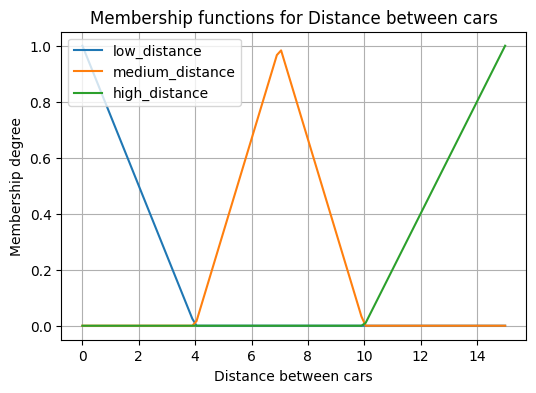

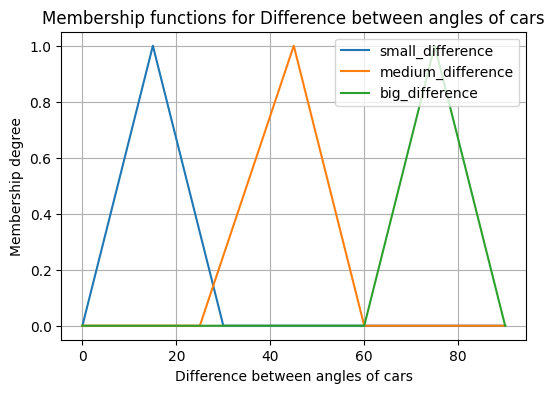

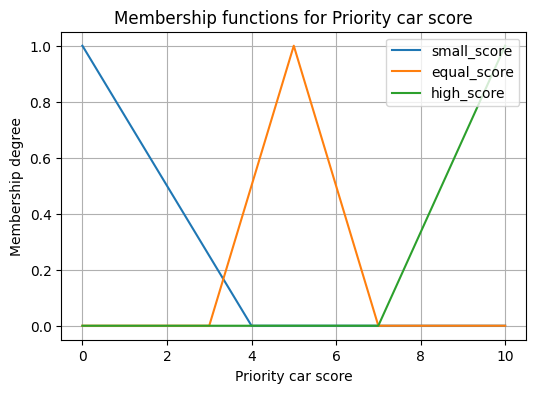

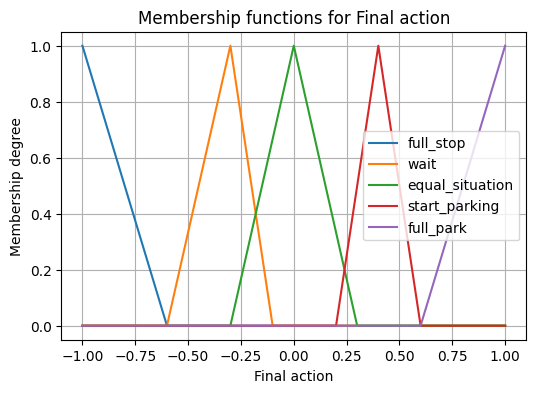

In [5]:
#Building graphs for our membership functions:
def plot_memberships(var, var_name):
    plt.figure(figsize=(6, 4))
    for term in var.terms:
        mf = var[term].mf
        plt.plot(var.universe, mf, label=term)
    plt.title(f"Membership functions for {var_name}")
    plt.xlabel(var_name)
    plt.ylabel("Membership degree")
    plt.legend()
    plt.grid(True)
    plt.show()
# Distance membership function
plot_memberships(car_distance, "Distance between cars")
# Angle membership function
plot_memberships(car_angles_diff, "Difference between angles of cars")
# Priority car score membership function
plot_memberships(priority_car_score, "Priority car score")
# Final action membership function
plot_memberships(final_action, "Final action")

In [6]:
#Rules based on matrices
rules = []

#Rules for small distance situation
rule1 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['small_score']),final_action['full_stop'])
rules.append(rule1)
rule2 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['equal_score']),final_action['wait'])
rules.append(rule2)
rule3 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['high_score']),final_action['full_stop'])
rules.append(rule3)
rule4 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['high_score']),final_action['wait'])
rules.append(rule4)
rule5 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['small_score']),final_action['full_stop'])
rules.append(rule5)
rule6 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['equal_score']),final_action['wait'])
rules.append(rule6)
rule7 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['equal_score']),final_action['full_stop'])
rules.append(rule7)
rule8 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['small_score']),final_action['full_stop'])
rules.append(rule8)
rule9 = ctrl.Rule((car_distance['low_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['high_score']),final_action['wait'])
rules.append(rule9)
#Rules for medium distance situation
rule10 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['small_score']),final_action['equal_situation'])
rules.append(rule10)
rule11 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['equal_score']),final_action['equal_situation'])
rules.append(rule11)
rule12 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['high_score']),final_action['wait'])
rules.append(rule12)
rule13 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['small_score']),final_action['full_stop'])
rules.append(rule13)
rule14 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['high_score']),final_action['full_park'])
rules.append(rule14)
rule15 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['equal_score']),final_action['start_parking'])
rules.append(rule15)
rule16 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['equal_score']),final_action['full_stop'])
rules.append(rule16)
rule17 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['small_score']),final_action['wait'])
rules.append(rule17)
rule18 = ctrl.Rule((car_distance['medium_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['high_score']),final_action['start_parking'])
rules.append(rule18)
#Rules for high distance situation
rule19 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['small_score']),final_action['equal_situation'])
rules.append(rule19)
rule20 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['equal_score']),final_action['equal_situation'])
rules.append(rule20)
rule21 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['high_score']),final_action['equal_situation'])
rules.append(rule21)
rule22 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['small_score']),final_action['wait'])
rules.append(rule22)
rule23 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['high_score']),final_action['full_park'])
rules.append(rule23)
rule24 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['small_difference'])&(priority_car_score['equal_score']),final_action['start_parking'])
rules.append(rule24)
rule25 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['big_difference'])&(priority_car_score['equal_score']),final_action['wait'])
rules.append(rule25)
rule26 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['small_score']),final_action['wait'])
rules.append(rule26)
rule27 = ctrl.Rule((car_distance['high_distance'])&(car_angles_diff['medium_difference'])&(priority_car_score['high_score']),final_action['full_park'])
rules.append(rule27)


In [7]:
#Fuzzy controller based on our rules
car_parking_ctrl=ctrl.ControlSystem(rules)
car_parking_simulation=ctrl.ControlSystemSimulation(car_parking_ctrl)

In [8]:
#Function to input the situation to get the actual results
def test_sim(test_distance, test_angle, test_priority):
    sim = ctrl.ControlSystemSimulation(car_parking_ctrl)

    sim.input['car_distance'] = test_distance
    sim.input['car_angles_diff'] = test_angle
    sim.input['priority_car_score'] = test_priority

    sim.compute()
    return sim.output['final_action']

In [9]:
# Numeric to verbal transition function
def interpret_action(value):
    if value<=-0.6:
        return "full_stop"
    elif value<=-0.1:
        return "wait"
    elif value<0.3:
        return "equal"
    elif value<0.8:
        return "start_parking"
    else:
        return "full_park"


In [10]:
# Test 1: low distance, medium angle difference, small priority score
result_test1=test_sim(test_distance=2, test_angle=40, test_priority=2)
print("Test case 1:\n"
f"Action is: {interpret_action(result_test1)} ({round(result_test1,3)})")
# Test 2: medium distance, big angle difference, equal priority score
result_test2=test_sim(test_distance=5, test_angle=77, test_priority=5)
print("Test case 2:\n"
f"Action is: {interpret_action(result_test2)} ({round(result_test2,3)})")
# Test 3: high distance, small angle difference, high priority score
result_test3=test_sim(test_distance=11, test_angle=5, test_priority=8)
print("Test case 3:\n"
f"Action is: {interpret_action(result_test3)} ({round(result_test3,3)})")
# Test 4: medium distance, medium angle difference, equal priority score
result_test4=test_sim(test_distance=5, test_angle=45, test_priority=5)
print("Test case 4:\n"
f"Action is: {interpret_action(result_test4)} ({round(result_test4,3)})")
# Test 5: high distance, small angle difference, equal priority score
result_test5=test_sim(test_distance=13, test_angle=12, test_priority=5)
print("Test case 5:\n"
f"Action is : {interpret_action(result_test5)} ({round(result_test5,3)})")
# Test 6: high distance, big angle difference, small priority score
result_test6=test_sim(test_distance=13, test_angle=85, test_priority=5)
print("Test case 6:\n"
f"Action is: {interpret_action(result_test6)} ({round(result_test6,3)})")




Test case 1:
Action is: full_stop (-0.844)
Test case 2:
Action is: full_stop (-0.831)
Test case 3:
Action is: full_park (0.819)
Test case 4:
Action is: equal (0.0)
Test case 5:
Action is : start_parking (0.4)
Test case 6:
Action is: wait (-0.342)


In [11]:
#Results:

#Test case 1: low distance, medium angle difference, small priority score
#Action is: full_stop (-0.844) - esults are negative, so we need to full stop, because the distance between cars is close, the priority score is small too and 
    #the angle is medium-also not ideal situation

#Test case 2: medium distance, big angle difference, equal priority score
#Action is: full_stop (-0.831) - results are also negative, because despite the fact that the distance is medium-we have a big angle difference,
#which is very important for parking, so we totally abort the situation and of course -equal priority score-that decides nothing here

#Test case 3: high distance, small angle difference, high priority score
#Action is: full_park (0.819) - results are very positive for parking, we have a small angle difference, high distance between the car and also high priority
    #score- there are all our green flags for the parking

#Test case 4: medium distance, medium angle difference, equal priority score
#Action is: equal (0.0) - results are mathing with our centroid, cos all values are perfectly in the middle, so we got 0 as a result and the 
    #situation is equal for both cars.

#Test case 5: high distance, small angle difference, equal priority score
#Action is: start_parking (0.4) - the result matches our input values, cos we dont have the ideal situation to fully park the car, but we have
    #high distance which add us safeness and a small angle difference-situation is pretty close to ideal.

#Test case 6: high distance, big angle difference, small priority score
#Action is: wait (-0.342) - result is predictable , cos we have situation which is close to "full stop", despite the fact that the distance between
    #the cars is high- the angle difference is huge and the car has a small priority score, which leads to the action "wait"

